# 區塊 0：環境設定與資料讀取

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 設定視覺化風格
sns.set_theme(style="whitegrid")

# 設定亂數種子，確保可重現性
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 確保輸出資料夾存在
os.makedirs("output", exist_ok=True)

# 讀取資料
df = pd.read_csv(r"data/mimic3c.csv")

# 初步預覽
display(df.head())

,hadm_id,gender,age,LOSdays,admit_type,admit_location,AdmitDiagnosis,insurance,religion,marital_status,...,NumMicroLabs,NumNotes,NumOutput,NumRx,NumProcEvents,NumTransfers,NumChartEvents,ExpiredHospital,TotalNumInteract,LOSgroupNum
0,100001,F,35,6.17,EMERGENCY,CLINIC REFERRAL/PREMATURE,DIABETIC KETOACIDOSIS,Private,PROTESTANT QUAKER,DIVORCED,...,0.65,0.05,5.19,14.91,1.13,0.65,398.70,0,493.89,2
1,100003,M,59,4.04,EMERGENCY,EMERGENCY ROOM ADMIT,UPPER GI BLEED,Private,NOT SPECIFIED,SINGLE,...,1.24,1.59,5.45,7.18,0.99,1.24,373.02,0,465.71,2
2,100006,F,48,12.04,EMERGENCY,EMERGENCY ROOM ADMIT,COPD FLARE,Private,NOT SPECIFIED,SINGLE,...,0.33,0.15,4.15,6.23,0.00,0.33,286.21,0,344.00,4
3,100007,F,73,7.29,EMERGENCY,EMERGENCY ROOM ADMIT,BOWEL OBSTRUCTION,Private,JEWISH,MARRIED,...,0.69,0.17,9.05,11.52,0.00,0.96,526.06,0,603.05,2
4,100009,M,60,4.88,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,CORONARY ARTERY DISEASE,Private,CATHOLIC,MARRIED,...,0.61,0.34,16.19,25.00,2.87,2.05,554.92,0,679.84,2


# 區塊 1：資料理解(Data Understanding)

## 1.1 欄位結構與型態

In [2]:
# 查看資料集大小與欄位型態
print(f"資料集維度: {df.shape}")
df.info()

# 分離數值與類別欄位以便後續分析
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

資料集維度: (58976, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58976 entries, 0 to 58975
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hadm_id           58976 non-null  int64  
 1   gender            58976 non-null  object 
 2   age               58976 non-null  int64  
 3   LOSdays           58976 non-null  float64
 4   admit_type        58976 non-null  object 
 5   admit_location    58976 non-null  object 
 6   AdmitDiagnosis    58951 non-null  object 
 7   insurance         58976 non-null  object 
 8   religion          58518 non-null  object 
 9   marital_status    48848 non-null  object 
 10  ethnicity         58976 non-null  object 
 11  NumCallouts       58976 non-null  float64
 12  NumDiagnosis      58976 non-null  float64
 13  NumProcs          58976 non-null  float64
 14  AdmitProcedure    58976 non-null  object 
 15  NumCPTevents      58976 non-null  float64
 16  NumInput          589

### 欄位臨床語意說明：
1. `ExpiredHospital`: 目標變數（Target），代表病患是否在住院期間死亡（0=存活，1=死亡）。這在臨床上是最直觀的預後指標。
2. `LOSdays`: Length of Stay，住院天數。通常反映了病患的嚴重程度與醫療資源消耗。
3. `admit_type`: 入院類型（如急診 Emergency、門診轉入等）。急診入院通常代表病情較危急。
4. `NumLabs`: 實驗室檢驗次數。次數越多可能代表病情較複雜，需要頻繁監測。
5. `TotalNumInteract`: 總互動次數（包含給藥、檢驗、處置等）。是醫療資源密集度的一個高度綜合指標。

## 1.2 缺失值與資料品質檢查

C:\Users\Austin\AppData\Local\Temp\ipykernel_32304\627127347.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Missing_Percentage', y='Feature', data=missing_df, palette='viridis')


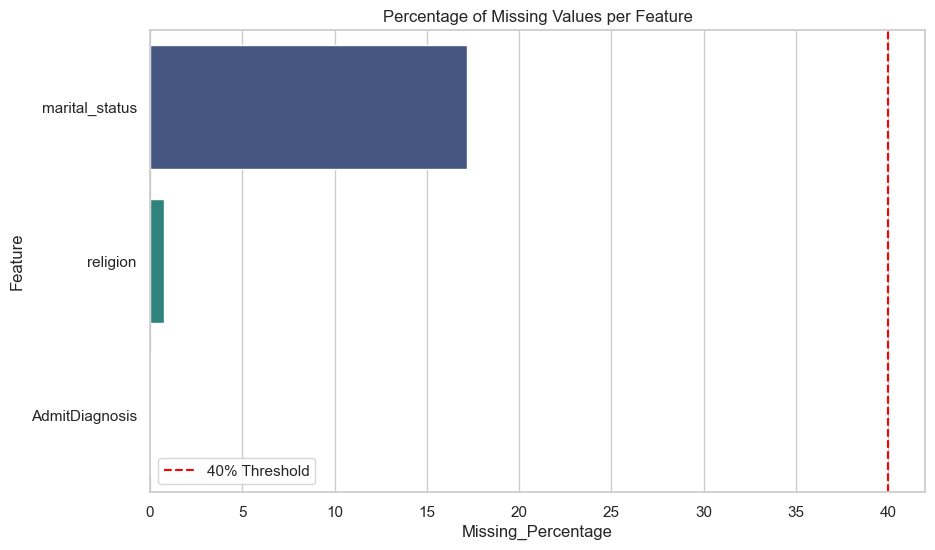

缺失率大於 40% 的欄位: []


In [3]:
# 計算各欄位缺失比例
missing_ratio = df.isnull().mean() * 100
missing_df = missing_ratio[missing_ratio > 0].sort_values(ascending=False).reset_index()
missing_df.columns = ['Feature', 'Missing_Percentage']

# 繪製缺失比例長條圖
plt.figure(figsize=(10, 6))
sns.barplot(x='Missing_Percentage', y='Feature', data=missing_df, palette='viridis')
plt.title('Percentage of Missing Values per Feature')
plt.axvline(x=40, color='red', linestyle='--', label='40% Threshold')
plt.legend()
plt.show()

# 印出高缺失欄位 (>40%)
high_missing_cols = missing_df[missing_df['Missing_Percentage'] > 40]['Feature'].tolist()
print(f"缺失率大於 40% 的欄位: {high_missing_cols}")

### 缺失值與資料品質觀察：
1. 本資料集資料品質相對良好，沒有任何欄位的缺失率大於40%
2. 缺失比例最高的欄位為`marital_status`(婚姻狀態，約17%)，這在真實電子病歷中很常見，可能是未填寫或病患無法回答，通常屬於隨機缺失(MCAR)
3. 其他如`religion`(約1%)與`AdmitDiagnosis`(極少)僅有零星缺失。由於沒有大於40%缺失的欄位，後續前處理不需捨棄任何特徵欄位，針對這些類別型變數可考慮使用眾數進行填補即可

# 區塊 2：探索性資料分析(EDA)

## 2.1 連續變數分佈與異常值觀察

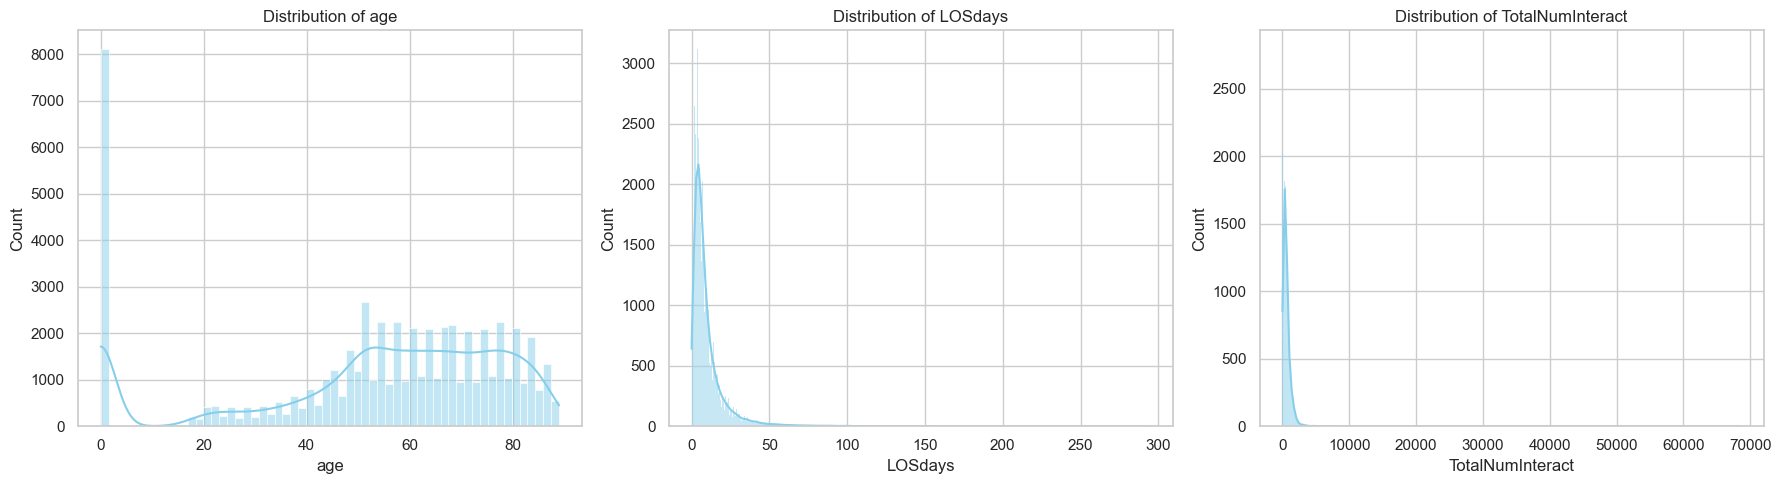

In [4]:
features_to_plot = ['age', 'LOSdays', 'TotalNumInteract'] # 假設資料集有 age

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(features_to_plot):
    if col in df.columns:
        sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## 2.2 類別變數與目標變數(ExpiredHospital)關係

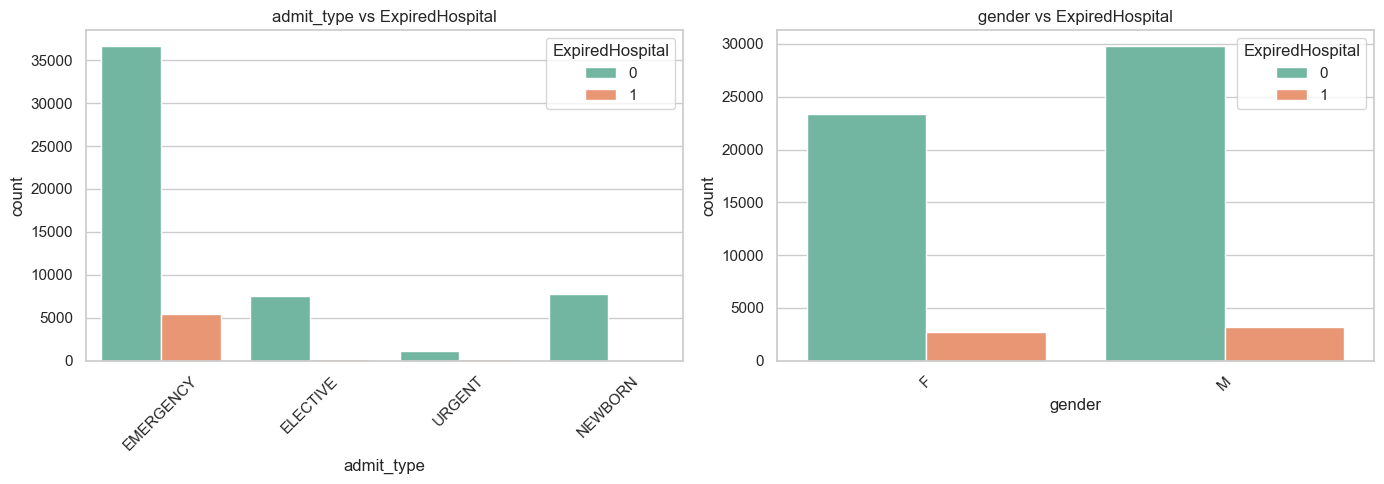

In [5]:
cat_features = ['admit_type', 'gender']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(cat_features):
    if col in df.columns:
        # 使用 countplot 觀察數量與比例
        sns.countplot(data=df, x=col, hue='ExpiredHospital', ax=axes[i], palette='Set2')
        axes[i].set_title(f'{col} vs ExpiredHospital')
        axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 2.3 重點統計表與具體觀察

In [6]:
# 範例：計算不同入院類型 (admit_type) 的病患人數、平均住院天數、以及死亡率
eda_key_stats = df.groupby('admit_type').agg(
    Patient_Count=('hadm_id', 'count'), # 假設有 hadm_id，否則用其他不缺失的欄位
    Avg_LOSdays=('LOSdays', 'mean'),
    Mortality_Rate=('ExpiredHospital', 'mean') # 因為是 0/1，mean 就是死亡率
).reset_index()

# 將死亡率轉為百分比方便閱讀
eda_key_stats['Mortality_Rate(%)'] = (eda_key_stats['Mortality_Rate'] * 100).round(2)
display(eda_key_stats)

# 儲存此表供後續 README/Markdown 引用與助教檢查
eda_key_stats.to_csv('output/eda_key_stats.csv', index=False)

,admit_type,Patient_Count,Avg_LOSdays,Mortality_Rate,Mortality_Rate(%)
0,ELECTIVE,7706,8.864606,0.025564,2.56
1,EMERGENCY,42071,10.017185,0.129163,12.92
2,NEWBORN,7863,11.496295,0.007885,0.79
3,URGENT,1336,12.275876,0.120509,12.05


### EDA具體觀察：
1. `LOSdays`(住院天數)呈現明顯的右偏分佈(長尾)，大多數病人住院天數集中在0-10天左右，但有極少數病患的住院天數高達近300天
2. `TotalNumInteract`同樣呈現高度右偏，少數病患的互動數值甚至可達近70,000次，代表醫療資源消耗在極少數重症病人身上極度集中，後續建模強烈建議做對數轉換(log-transform)
3. 從病患年齡(`age`)的分佈來看，除了主群體集中在50-80歲的中老年族群外，在0歲處有一個極大的突起，代表資料集中包含了大量的新生兒
4. 從入院類型來看，以`EMERGENCY`(急診)入院的病患人數最多，共計高達42,071人。且從統計表可見，急診入院的死亡率高達12.92%，明顯高於`ELECTIVE`(排程入院)的2.56%
5. `NEWBORN`(新生兒)族群的人數為7,863人，其死亡率是所有入院類型中最低的(僅0.79%)；但值得注意的是，其平均住院天數(11.50天)卻高於急診(10.02天)與排程入院(8.86天)，顯示新生兒雖然存活率高，但通常需要較長時間的留院觀察與照護

# 區塊 3：前處理與特徵工程

In [7]:
df_clean = df.copy()

## 3.1 缺失值處理策略

In [8]:
# 1. 捨棄高缺失率欄位 (>40%)
df_clean = df_clean.drop(columns=high_missing_cols)

# 2. 連續型變數 (表示為 0 或 NaN)：以中位數填補
for col in numeric_cols:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        # 如果題目說缺失值被記為 0，可以使用 df_clean[col] = df_clean[col].replace(0, median_val)

# 3. 類別型變數：以眾數 (Mode) 填補
for col in categorical_cols:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)

### 處理理由
* 連續型：使用中位數填補，因為從EDA發現多數數值有長尾分佈(如 LOSdays)，中位數不受極端值影響，統計上較穩健
* 類別型：使用眾數填補，因為缺失比例不高(最高如marital_status為17%)，填補多數類別能最大程度維持原有的資料分佈
* 高缺失欄位：由於檢查後發現本次資料並沒有缺失率>40%的欄位，因此不需要捨棄任何整欄特徵

## 3.2 至少兩種特徵工程(範例：特徵建構 + 對數轉換/標準化)

In [ ]:
# 建構新特徵：醫療資源密集度 (Resource Intensity)
# 邏輯：總互動次數 / (住院天數 + 1) -> 避免分母為 0
df_clean['resource_intensity'] = df_clean['TotalNumInteract'] / (df_clean['LOSdays'] + 1)

# 建構新特徵：是否為長住院病人 (長於 14 天)
df_clean['long_LOS_flag'] = (df_clean['LOSdays'] > 14).astype(int)

In [ ]:
from sklearn.preprocessing import StandardScaler

# 處理高度右偏的特徵：使用 log1p (log(x+1)) 轉換
skewed_features = ['TotalNumInteract', 'NumLabs', 'resource_intensity']
for col in skewed_features:
    if col in df_clean.columns:
        df_clean[f'{col}_log'] = np.log1p(df_clean[col])
        df_clean = df_clean.drop(columns=[col]) # 捨棄原始高度偏態的欄位

# (可選) 對數值變數進行標準化
scaler = StandardScaler()
num_cols_to_scale = df_clean.select_dtypes(include=['float64', 'int64']).columns
df_clean[num_cols_to_scale] = scaler.fit_transform(df_clean[num_cols_to_scale])

## 3.3 類別變數編碼(Encoding)

In [ ]:
# 找出剩下的類別型欄位
remaining_cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# 使用 One-Hot Encoding (pd.get_dummies)
df_model_ready = pd.get_dummies(df_clean, columns=remaining_cat_cols, drop_first=True)

# 確保所有欄位名稱都是字串 (避免部分 sklearn 報錯)
df_model_ready.columns = df_model_ready.columns.astype(str)

# 區塊 4：輸出可建模資料表(Analysis-Ready Table)

In [ ]:
# 檢查是否還有缺失值 (應為 0)
print(f"剩餘缺失值總數: {df_model_ready.isnull().sum().sum()}")

# 檢查 DataFrame 維度與型態
print(f"Model-Ready 資料維度: {df_model_ready.shape}")

# 將目標變數 ExpiredHospital 移到第一欄或最後一欄
target_col = 'ExpiredHospital'
if target_col in df_model_ready.columns:
    cols = [target_col] + [c for c in df_model_ready.columns if c != target_col]
    df_model_ready = df_model_ready[cols]

# 自動輸出成 CSV 到 output/ 目錄下
df_model_ready.to_csv("output/df_model_ready.csv", index=False)
print("✅ df_model_ready.csv 已經成功儲存至 output/ 目錄中！")

剩餘缺失值總數: 0
Model-Ready 資料維度: (58976, 17068)
✅ df_model_ready.csv 已經成功儲存至 output/ 目錄中！
